In [52]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.special import gammaln

In [14]:
data = np.load("/Users/egeacareti/Statistics-Course/Statistics_meerburg_2026_fork/Lectures/data/higgs_binned.npy")
inv_m = data[:, 0]
n = data[:, 1]
delta_m = data[:, 2]
N = len(inv_m)

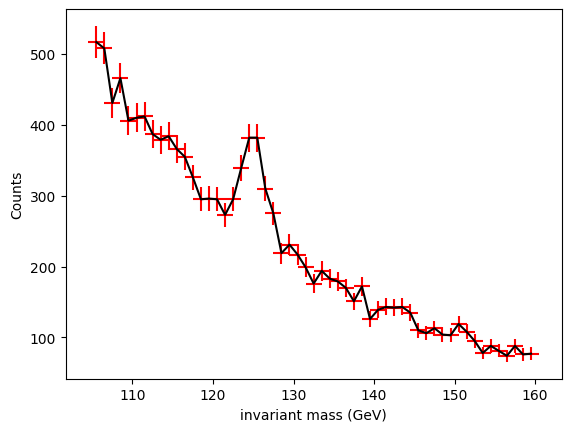

In [15]:
plt.errorbar(inv_m, n, yerr=np.sqrt(n), xerr=delta_m, ecolor = "red", color = "black")
plt.xlabel("invariant mass (GeV)")
plt.ylabel("Counts")
plt.show()

In [84]:
def model(mu, sigma, alpha, A, B, m, delta_m):
    events = delta_m * (A * np.exp(- (m-mu)**2 / (2*sigma**2)) + B * np.exp(-alpha * m))
    return events

def logL(theta, m, num, delta_m):
    mu, sigma, alpha, A, B = theta
    events = model(mu, sigma, alpha, A, B, m, delta_m)
    if np.any(events <= 0):
        return -np.inf
    
    logL = num * np.log(events) - events - gammaln(num+1)
    result = np.sum(logL)
    return result

def log_prior(theta):
    mu, sigma, alpha, A, B = theta
    if 110 < mu < 140 and 0.5 < sigma < 5 and -5 < np.log(alpha) < 1 and 0 < A < 10000 and 0 < B < 50000:
        return 0.0
    return -np.inf

def LogPosterior(theta, m, num, delta_m):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = logL(theta, m, num, delta_m)
    if np.isnan(ll):
        return -np.inf
    return lp + ll
print(n)

[517. 508. 431. 466. 406. 410. 412. 387. 379. 384. 366. 355. 326. 295.
 296. 295. 273. 295. 339. 382. 382. 310. 275. 219. 231. 217. 199. 176.
 194. 183. 179. 170. 151. 172. 126. 139. 143. 142. 143. 135. 110. 106.
 113. 104. 103. 119. 108.  95.  78.  88.  81.  74.  88.  76.  77.]


In [88]:
ndim = 5
nwalkers = 30
burn = 1000  
nsteps = 5000 

starting_guesses = np.array([125, 2, 0.2, 5000, 25000])
initial_pos = starting_guesses + 1e-4 * np.random.randn(nwalkers, ndim)
for i, pos in enumerate(initial_pos):
    prob = LogPosterior(pos, inv_m, n, delta_m)
    if not np.isfinite(prob):
        print(f"Walker {i} is starting in an 'illegal' region! Prob: {prob}")
        print(f"Parameters: {pos}")
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, args=[inv_m, n, delta_m])
sampler.run_mcmc(initial_pos, nsteps)

/var/folders/sx/ksz1y5xj7751_tpm6ywmv45c0000gn/T/ipykernel_71601/2228500972.py:17: RuntimeWarning: invalid value encountered in log
  if 110 < mu < 140 and 0.5 < sigma < 5 and -5 < np.log(alpha) < 1 and 0 < A < 10000 and 0 < B < 50000:


State([[1.25386003e+02 1.26756312e+00 3.63414523e-02 1.22054826e+02
  2.33505585e+04]
 [1.24851589e+02 1.36042878e+00 3.54653659e-02 1.40460442e+02
  2.13036812e+04]
 [1.24994756e+02 1.52217412e+00 3.60391992e-02 1.20977805e+02
  2.28919129e+04]
 [1.25102570e+02 1.23396587e+00 3.56631783e-02 1.36543373e+02
  2.18905466e+04]
 [1.24966331e+02 1.45336089e+00 3.57355026e-02 1.39343199e+02
  2.20985345e+04]
 [1.25360948e+02 1.14861216e+00 3.55134727e-02 1.49190281e+02
  2.10685797e+04]
 [1.15484426e+02 9.39813297e-01 3.60944398e-02 1.06224174e+00
  2.34610111e+04]
 [1.25213844e+02 1.48669680e+00 3.49235687e-02 1.45012256e+02
  1.94237295e+04]
 [1.25226947e+02 1.52305110e+00 3.43022264e-02 1.43363736e+02
  1.79610317e+04]
 [1.24881198e+02 1.12929960e+00 3.61679934e-02 1.39187043e+02
  2.34090547e+04]
 [1.25053778e+02 1.52766967e+00 3.53969157e-02 1.40672241e+02
  2.07592448e+04]
 [1.24846051e+02 1.35287733e+00 3.48055992e-02 1.42862053e+02
  1.91606285e+04]
 [1.24913776e+02 1.29708641e+00 3.

mu = 125.077 +0.299/-11.165
sigma = 1.383 +0.324/-0.488
alpha = 0.035 +0.001/-0.001
A = 133.907 +27.429/-127.490
B = 21241.269 +2923.122/-2608.306


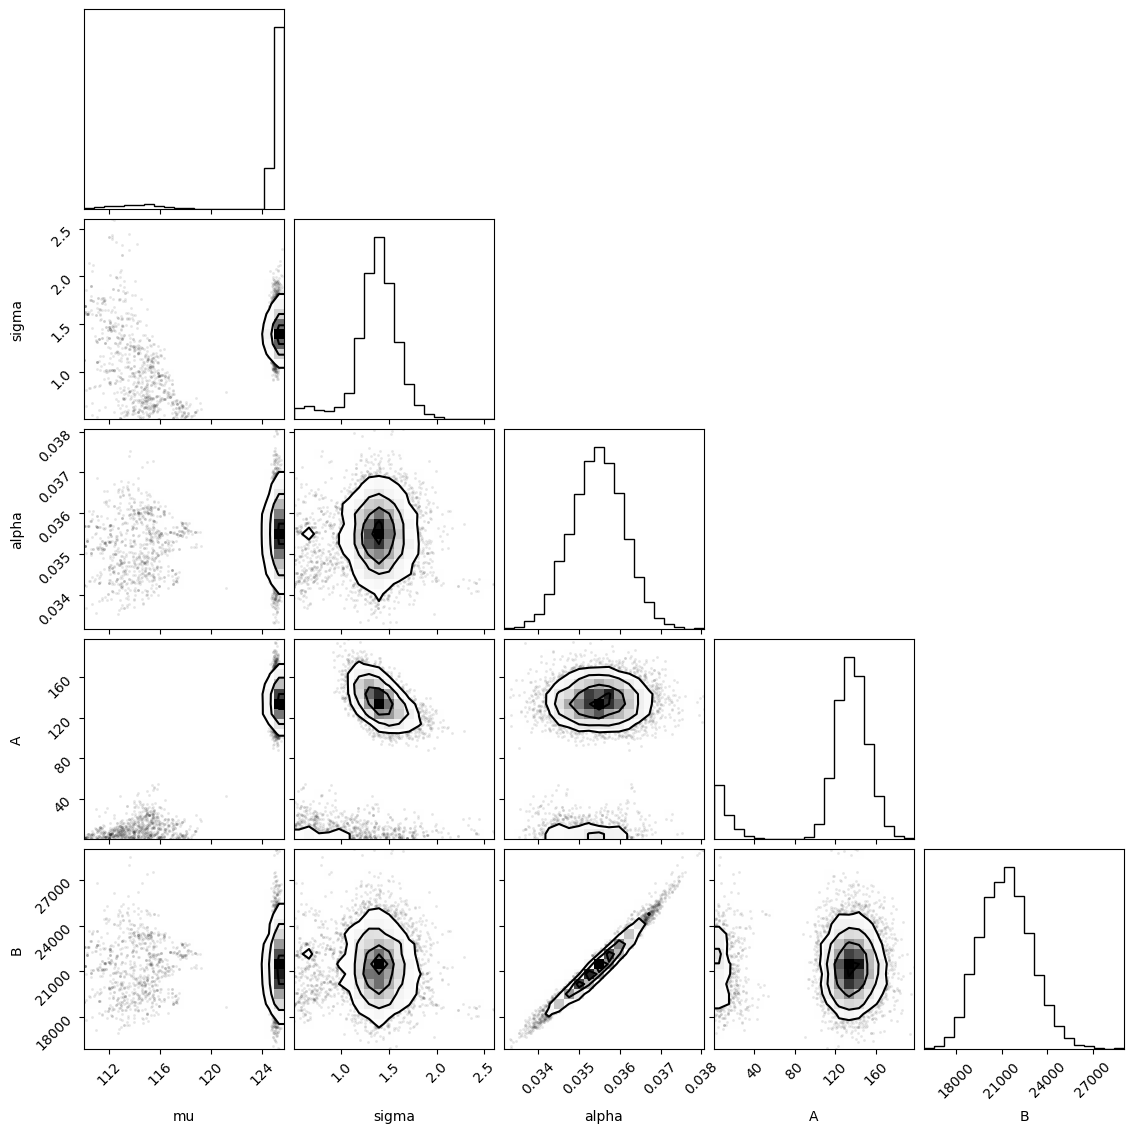

In [89]:
# Flatten samples and remove burn-in
flat_samples = sampler.get_chain(discard=burn, thin=15, flat=True)

labels = ["mu", "sigma", "alpha", "A", "B"]
results = {}

for i in range(ndim):
    # Calculate 5th, 50th (median), and 95th percentiles for a 90% interval
    mcmc = np.percentile(flat_samples[:, i], [5, 50, 95])
    q = np.diff(mcmc)
    results[labels[i]] = (mcmc[1], q[0], q[1])
    print(f"{labels[i]} = {mcmc[1]:.3f} +{q[1]:.3f}/-{q[0]:.3f}")

# Visualizing the results
fig = corner.corner(flat_samples, labels=labels)
plt.show()